In [1]:
import pandas as pd
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
s = 0.1
ne_list = [100,1000]
df_list = []
for ne in ne_list:
    df = pd.read_csv('results/median_{ne}_s_{s}_df.csv'.format(ne=ne,s=s))
    df_list.append(df)

In [3]:
df_list_with_ne = []
for i, df in enumerate(df_list):
    df_copy = df.copy()
    df_copy['ne'] = ne_list[i] 
    df_list_with_ne.append(df_copy)

merged_df = pd.concat(df_list_with_ne, ignore_index=True)
merged_df['ne'] = pd.Categorical(merged_df['ne'], categories=[100, 1000])

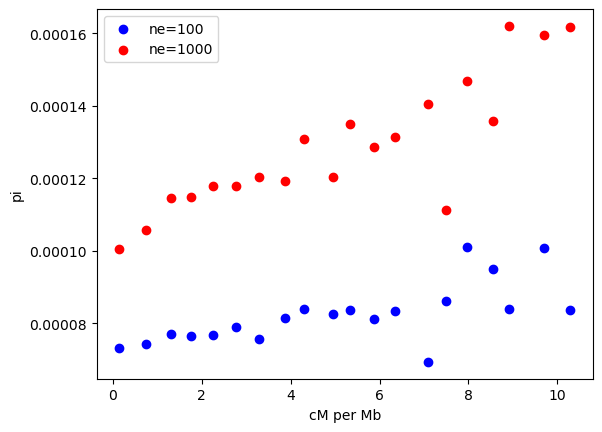

In [4]:
colors = ['blue', 'red']
for i, ne_val in enumerate([100, 1000]):
    mask = merged_df['ne'] == ne_val
    plt.scatter(merged_df[mask]['cm_mb'], merged_df[mask]['pi'],
                c=colors[i], label=f'ne={ne_val}')
    plt.xlabel('cM per Mb')
    plt.ylabel('pi')
plt.legend()

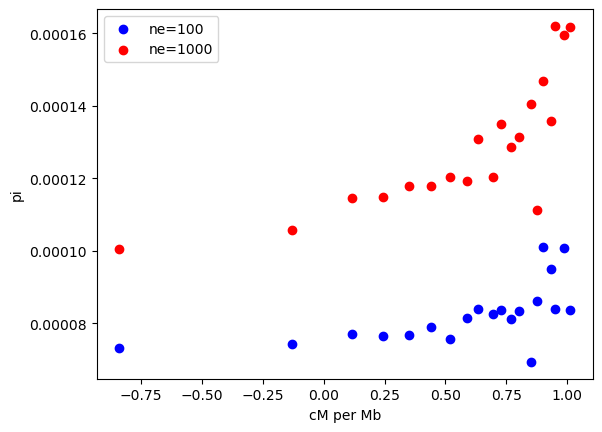

In [5]:
colors = ['blue', 'red']
for i, ne_val in enumerate([100, 1000]):
    mask = merged_df['ne'] == ne_val
    plt.scatter(np.log10(merged_df[mask]['cm_mb']), merged_df[mask]['pi'],
                c=colors[i], label=f'ne={ne_val}')
    plt.xlabel('cM per Mb')
    plt.ylabel('pi')
plt.legend()

In [6]:
# PYMC hierarchical model 
with pm.Model() as hierarchical_model:
    # Convert categorical ne to numeric indices
    ne_idx = pm.ConstantData("ne_idx", merged_df['ne'].cat.codes.values)
    log_cm_mb = pm.ConstantData("log_cm_mb", np.log10(merged_df['cm_mb'].values))
    pi_obs = pm.ConstantData("pi_obs", merged_df['pi'].values)
    
    # Hyperpriors for group-level parameters
    mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=1)  # Group mean for intercept
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)  # Group variation for intercept
    
    mu_beta = pm.Normal("mu_beta", mu=0, sigma=1)  # Group mean for slope
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=0.5)  # Group variation for slope
    
    # Group-specific parameters (one for each ne level)
    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha, shape=2)  # Intercepts
    beta = pm.Normal("beta", mu=mu_beta, sigma=sigma_beta, shape=2)  # Slopes
    
    # Linear predictor
    mu = alpha[ne_idx] + beta[ne_idx] * log_cm_mb
    
    # Likelihood
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    pi_pred = pm.Normal("pi_pred", mu=mu, sigma=sigma, observed=pi_obs)

print("Model created successfully!")

Model created successfully!


In [7]:
# Sample from priors
with hierarchical_model:
    prior_samples = pm.sample_prior_predictive(samples=1000, random_seed=42)
    


Sampling: [alpha, beta, mu_alpha, mu_beta, pi_pred, sigma, sigma_alpha, sigma_beta]


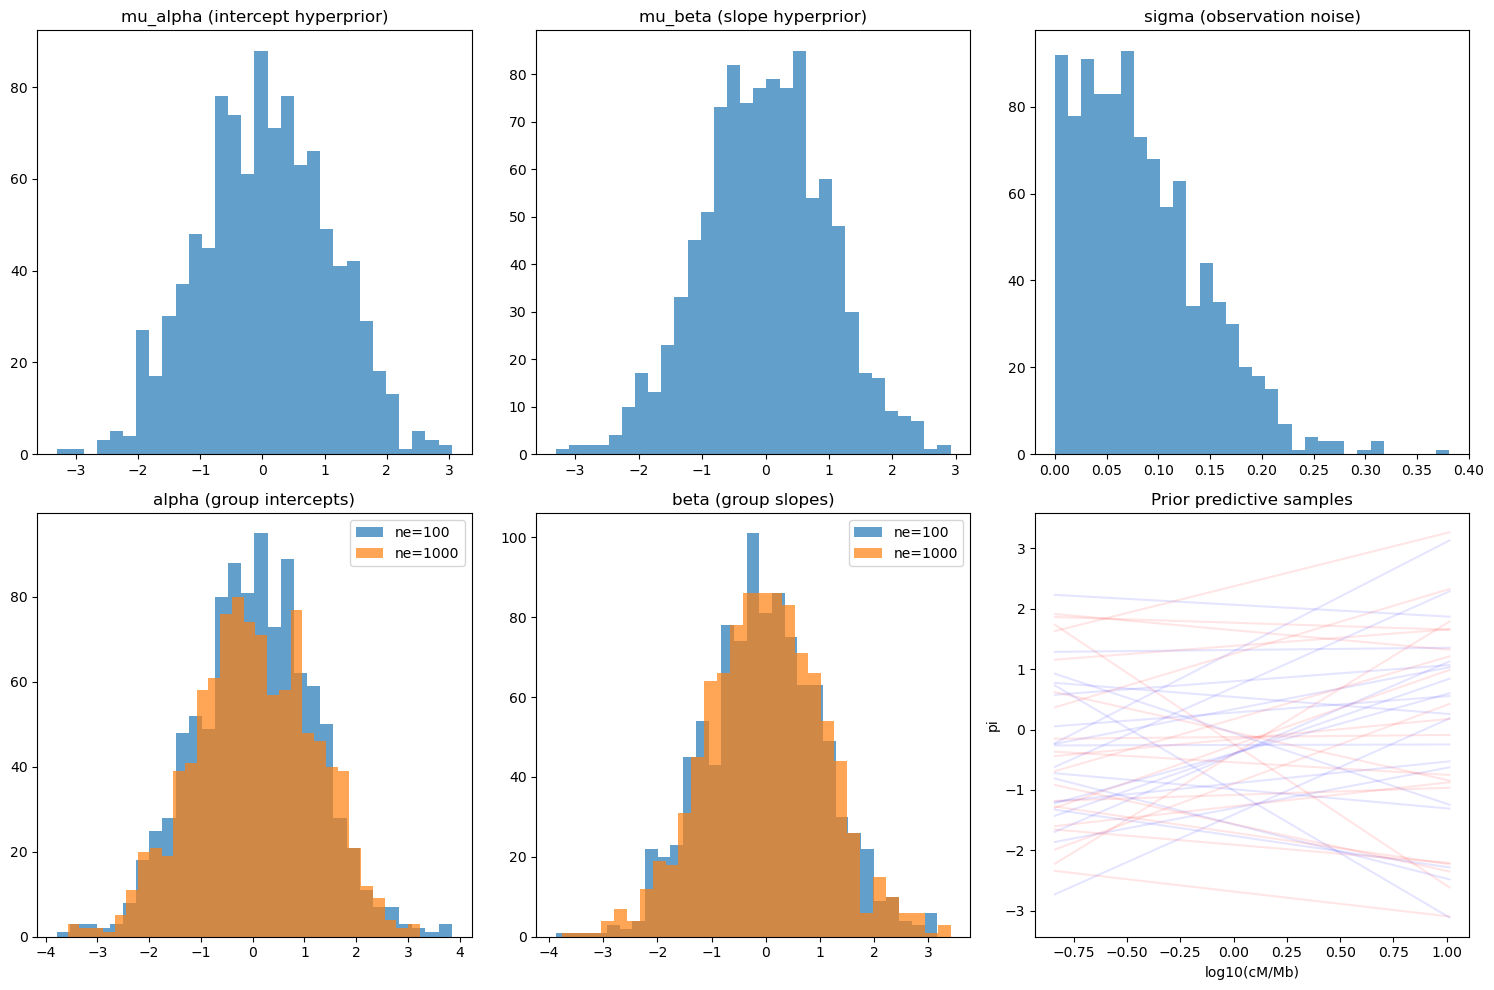

In [8]:
# Visualize prior samples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot hyperpriors
axes[0, 0].hist(prior_samples.prior['mu_alpha'].values.flatten(), bins=30, alpha=0.7)
axes[0, 0].set_title('mu_alpha (intercept hyperprior)')

axes[0, 1].hist(prior_samples.prior['mu_beta'].values.flatten(), bins=30, alpha=0.7)
axes[0, 1].set_title('mu_beta (slope hyperprior)')

axes[0, 2].hist(prior_samples.prior['sigma'].values.flatten(), bins=30, alpha=0.7)
axes[0, 2].set_title('sigma (observation noise)')

# Plot group-specific parameters - fix indexing to account for chain dimension
axes[1, 0].hist(prior_samples.prior['alpha'].values[0, :, 0], bins=30, alpha=0.7, label='ne=100')
axes[1, 0].hist(prior_samples.prior['alpha'].values[0, :, 1], bins=30, alpha=0.7, label='ne=1000')
axes[1, 0].set_title('alpha (group intercepts)')
axes[1, 0].legend()

axes[1, 1].hist(prior_samples.prior['beta'].values[0, :, 0], bins=30, alpha=0.7, label='ne=100')
axes[1, 1].hist(prior_samples.prior['beta'].values[0, :, 1], bins=30, alpha=0.7, label='ne=1000')
axes[1, 1].set_title('beta (group slopes)')
axes[1, 1].legend()

# Plot some prior predictive samples - fix indexing
log_cm_range = np.linspace(np.log10(merged_df['cm_mb'].min()), 
                          np.log10(merged_df['cm_mb'].max()), 100)

for i in range(20):  # Plot 20 random prior samples
    for ne_val in [0, 1]:  # For both ne categories
        alpha_sample = prior_samples.prior['alpha'].values[0, i, ne_val]  # Add chain index
        beta_sample = prior_samples.prior['beta'].values[0, i, ne_val]   # Add chain index
        pi_pred = alpha_sample + beta_sample * log_cm_range
        
        color = 'blue' if ne_val == 0 else 'red'
        axes[1, 2].plot(log_cm_range, pi_pred, color=color, alpha=0.1)

axes[1, 2].set_title('Prior predictive samples')
axes[1, 2].set_xlabel('log10(cM/Mb)')
axes[1, 2].set_ylabel('pi')

plt.tight_layout()
plt.show()

In [10]:
# Sample posterior
with hierarchical_model:
    trace = pm.sample(2000, tune=2000, target_accept=0.95, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, alpha, beta, sigma]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 430 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 702 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
